In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X = [0.5, 2.3, 2.9]
Y = [1.4,1.9,3.2]

plt.scatter(X,Y)
for x, y in zip(X,Y):
    plt.text(x, y+0.05, f"{x}, {y}")
#y = kx + b
#Допустим, что мы знаем значение k = 0.64
#y = 0.64x + b

def y_pred(x,b):
    return 0.64*x+b

#Предлположим что b = 0
x = np.linspace(0,5,10)
y = [y_pred(value, 0) for value in x]
y2 = [y_pred(value, 0.25) for value in x]
y3 = [y_pred(value, 0.95) for value in x]
plt.plot(x,y, label = 'b = 0')
# plt.plot(x,y3,label = 'b = 0.94' )
Y_pred = [round(y_pred(value, 0),2) for value in X]
plt.scatter(X, Y_pred)
for x, y in zip(X, Y_pred):
     plt.text(x, y-0.15, f"{x}, {y}")


plt.legend()
plt.show()

In [ ]:
F_1 = [(1.4-0.32)**2+(1.9-1.47)**2+(3.2-1.86)**2] #Функция потерь - Среднеквадратичная ошибка (MSE - mean square error)
b = 0
plt.scatter(b, F_1)
plt.xlim(-0.01)
plt.xlabel("b")
plt.ylabel("F_loss")
plt.axhline(0, color = 'black')
plt.axvline(0, color = 'black')


In [ ]:
def F(b):
    return ((1.4-(0.64*0.5+b))**2) + ((1.9-(0.64*2.3+b))**2) + ((3.2-(0.64*2.9+b))**2)

for b in np.linspace(-20,20, 50):
    plt.scatter(b, F(b), color = 'k')
    # print(f" b = {round(b,3)}, F(b) = {round(F(b),3)}")

In [ ]:
def derivative_F(b):
    return -2*(1.4-(0.64*0.5+b)) - 2*(1.9-(0.64*2.3+b)) - 2*(3.2-(0.64*2.9+b))
b = 0
print(f" производная F_loss при b = 0 равна {derivative_F(b)}")
alpha = 0.1
step_size = derivative_F(b)*alpha
print(f"размер шага равен {step_size}")
b = b - step_size
print(f"следующее b равно {b}")

i = 0
while(abs(step_size)>0.001):
    print(f" производная F_loss равна {derivative_F(b)}")
    step_size = derivative_F(b) * alpha
    print(f"размер шага равен {step_size}")
    b = b-step_size
    print(f"следующее b равно {b}")
    i+=1
    print("")
print(f"количество итераций равно {i}")    



In [ ]:



b = 0.1
k = 0.1
alpha = 0.0001
def derivative_F_b(b,k):
    return -2*(1.4-(k*0.5+b)) - 2*(1.9-(k*2.3+b)) - 2*(3.2-(k*2.9+b))

def derivative_F_k(b,k):
    return -2*0.5*(1.4-(k*0.5+b)) - 2*2.3*(1.9-(k*2.3+b)) - 2*2.9*(3.2-(k*2.9+b))

# print(f"значение производной по b = {derivative_F_b(b,k)}")
# print(f"значение производной по k = {derivative_F_k(b,k)}")

step_size_b = derivative_F_b(b,k)*alpha
step_size_k = derivative_F_k(b,k)*alpha

# print(f"значение шага по b равно {step_size_b}")
# print(f"значение шага по k равно {step_size_k}")
b = b-step_size_b
k = k - step_size_k

# print(f"новое значение b равно {b}")
# print(f"новое значение k равно {k}")
i = 0
while(abs(step_size_b)>1e-12 and abs(step_size_k)>1e-12):
    step_size_b = derivative_F_b(b,k)*alpha
    step_size_k = derivative_F_k(b,k)*alpha
    b = b-step_size_b
    k = k - step_size_k
    i+=1

print(f"номер итерации {i}")
print(f"значение b = {round(b,2)}")
print(f"значение k = {round(k,2)}")

In [ ]:
import pandas as pd
df = pd.read_csv('housing.csv')
print(df.head())
print(df.columns)

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('housing.csv') 

X = df['median_income'].values
y = df['median_house_value'].values / 1000  
n = 20000

b = 0.1
k = 0.1
alpha = 0.0001 
i = 0

def calculate_mse(b, k, X, y):
    return np.mean((y - (k * X + b))**2)

def derivative_F_b(b, k, X, y):
    return -2 * np.sum(y - (k * X + b)) / n

def derivative_F_k(b, k, X, y):
    return -2 * np.sum(X * (y - (k * X + b))) / n

# 4. Цикл
step_size_b = 1.0
step_size_k = 1.0

print(f"Старт. Начальный MSE: {calculate_mse(b, k, X, y):.2f}")

while(abs(step_size_b) > 1e-7 or abs(step_size_k) > 1e-7):
    step_size_b = derivative_F_b(b, k, X, y) * alpha
    step_size_k = derivative_F_k(b, k, X, y) * alpha
    
    b = b - step_size_b
    k = k - step_size_k
    i += 1
    
    if i % 10000 == 0:
        print(f"Итерация {i}: MSE = {calculate_mse(b, k, X, y):.2f}")
    
    if i > 100000: break

print("-" * 30)
print(f"Итого итераций: {i}")
print(f"Коэффициенты: k = {round(k, 2)}, b = {round(b, 2)}")
print(f"Финальный MSE: {calculate_mse(b, k, X, y):.2f}")

def calculate_accuracy(b, k, X, y, delta):
    
    return np.mean(np.abs(y - (k * X + b)) < delta) * 100

delta = 70
acc = calculate_accuracy(b, k, X, y, delta)
print(f"Точность: {acc:.2f}%")

def calculate_classification_metrics(b, k, X, y, delta):
    y_pred = k * X + b
    
  
    error = np.abs(y - y_pred)
    
   
    
    
    from sklearn.metrics import precision_score, recall_score
    
   
    threshold = 200
    y_true_binary = (y > threshold).astype(int)
    y_pred_binary = (y_pred > threshold).astype(int)
    
    prec = precision_score(y_true_binary, y_pred_binary)
    rec = recall_score(y_true_binary, y_pred_binary)
    
    return prec, rec

# Использование
prec, rec = calculate_classification_metrics(b, k, X, y, delta)

print(f"Precision (для домов > 200k): {prec:.2f}")
print(f"Recall (для домов > 200k): {rec:.2f}")

# Сначала вычисляем предсказания модели
y_pred = k * X + b

# Теперь считаем TP и FP
TP = np.sum((y_pred > 200) & (y > 200))
FP = np.sum((y_pred > 200) & (y <= 200))

manual_precision = TP / (TP + FP) if (TP + FP) > 0 else 0
print(f"Ручной Precision: {manual_precision:.2f}")



In [ ]:
#Логистическая регресиия (линейная классификация)
#Зададча: классификации присвоить обьекту не который  класс. Плоскость которой делит данные в трех мерном.
#Чтобы  классифицировать обьекты  нужно найти гиперплоскость "что она наиболее правдоподобной ". a(x)=B2d2 +p2d2+....+B0 =0
#a(x)=sgn(.....)/
#
#

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Генерируем данные (100 объектов)
np.random.seed(42)
X = np.linspace(-5, 5, 100) # 100 точек от -5 до 5

# Создаем вероятность через сигмоиду и добавляем случайности
prob = 1 / (1 + np.exp(-X)) 
y = (prob > np.random.rand(100)).astype(int) # Получаем 0 или 1

# 2. Строим график
plt.figure(figsize=(10, 5))
plt.scatter(X, y, c=y, cmap='bwr', edgecolors='k', label='Данные (0 или 1)')
plt.plot(X, prob, color='green', label='Идеальная кривая (вероятность)')

plt.title('Датасет для логистической регрессии')
plt.xlabel('Признак X')
plt.ylabel('Класс / Вероятность')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))




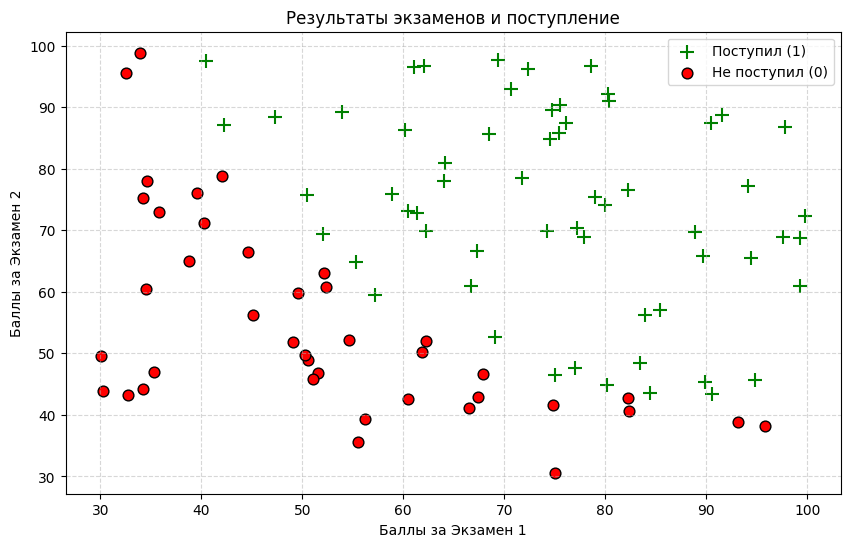

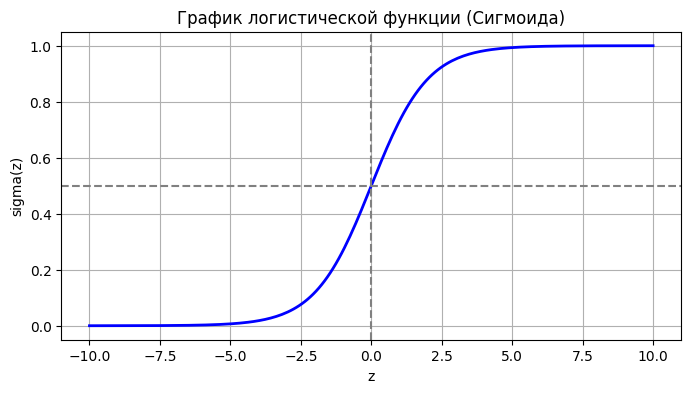

Оптимальные коэффициенты (theta): [-25.16133643   0.20623177   0.2014716 ]
Уравнение прямой: -25.1613 + 0.2062*x1 + 0.2015*x2 = 0
Выраженная функция: x2 = (--25.1613 - 0.2062*x1) / 0.2015


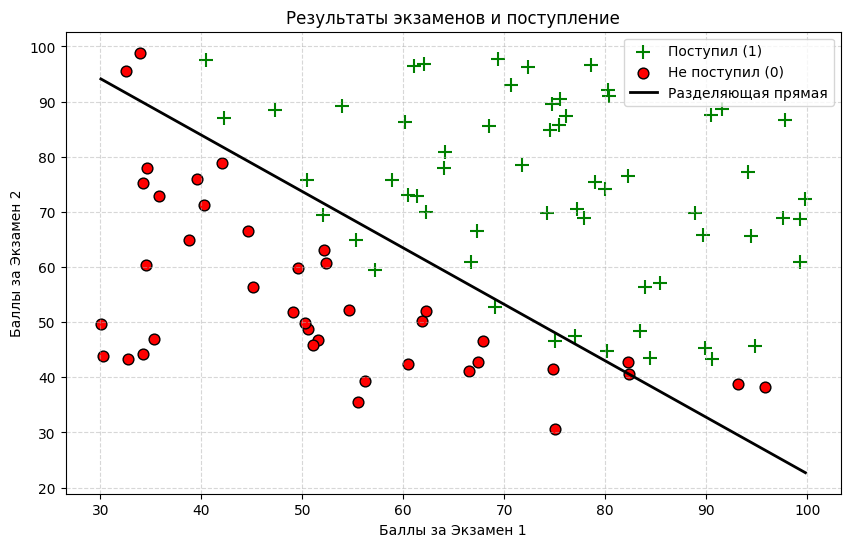


--- ТЕСТИРОВАНИЕ И ТОЧНОСТЬ ---
Вероятность поступления студента с баллами (45, 85): 77.63%
Точность (Accuracy) модели на тренировочных данных: 89.00%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

 
 

file_path = 'ex_data.txt' 


data = np.loadtxt(file_path, delimiter=',')

X_data = data[:, 0:2] 
y_data = data[:, 2]   



def plot_data(X, y):
    plt.figure(figsize=(10, 6))
    pos = y == 1
    neg = y == 0
    plt.scatter(X[pos, 0], X[pos, 1], marker='+', c='green', s=100, label='Поступил (1)')
    plt.scatter(X[neg, 0], X[neg, 1], marker='o', c='red', edgecolors='black', s=60, label='Не поступил (0)')
    plt.xlabel('Баллы за Экзамен 1')
    plt.ylabel('Баллы за Экзамен 2')
    plt.title('Результаты экзаменов и поступление')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

plot_data(X_data, y_data)
plt.savefig('scatter_plot.png')
plt.show()


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


z_values = np.linspace(-10, 10, 200)
plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid(z_values), color='blue', lw=2) 
plt.axvline(0, color='gray', linestyle='--')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('График логистической функции (Сигмоида)')
plt.xlabel('z')
plt.ylabel('sigma(z)')
plt.grid(True)
plt.savefig('sigmoid.png')
plt.show()


m, n = X_data.shape

X = np.hstack((np.ones((m, 1)), X_data))
y = y_data.reshape(-1, 1)
initial_theta = np.zeros(n + 1)


def cost_function(theta, X, y):
    m = len(y)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps) 
    cost = -1/m * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h))
    return cost.item()

def gradient_function(theta, X, y):
    m = len(y)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    grad = 1/m * (X.T @ (h - y))
    return grad.flatten() 


res = minimize(fun=cost_function, 
               x0=initial_theta, 
               args=(X, y), 
               jac=gradient_function, 
               method='BFGS')

theta_opt = res.x



print(f"Оптимальные коэффициенты (theta): {theta_opt}")
print(f"Уравнение прямой: {theta_opt[0]:.4f} + {theta_opt[1]:.4f}*x1 + {theta_opt[2]:.4f}*x2 = 0")
print(f"Выраженная функция: x2 = (-{theta_opt[0]:.4f} - {theta_opt[1]:.4f}*x1) / {theta_opt[2]:.4f}")


plot_data(X_data, y_data)
plot_x = np.array([np.min(X_data[:, 0]), np.max(X_data[:, 0])])
plot_y = (-theta_opt[0] - theta_opt[1] * plot_x) / theta_opt[2]

plt.plot(plot_x, plot_y, color='black', linestyle='-', linewidth=2, label='Разделяющая прямая')
plt.legend()
plt.savefig('decision_boundary.png')
plt.show()


student_scores = np.array([1, 45, 85]) 
prob = sigmoid(student_scores @ theta_opt)
print("\n--- ТЕСТИРОВАНИЕ И ТОЧНОСТЬ ---")
print(f"Вероятность поступления студента с баллами (45, 85): {prob * 100:.2f}%")

def predict(theta, X):
    probabilities = sigmoid(X @ theta.reshape(-1, 1))
    return (probabilities >= 0.5).astype(int)

predictions = predict(theta_opt, X)
accuracy = np.mean(predictions == y) * 100
print(f"Точность (Accuracy) модели на тренировочных данных: {accuracy:.2f}%")
